# Lorenz63: Chaotic ODE

In this notebook, we consider a multivariate ODE system called **Lorenz63**. This system has a chaotic regime depending on the initial values which proves to be very difficult for ODE solvers. However, using observations, `dalton` is able compute the correct solutions. The Lorenz equation is defined as follows:

\begin{equation*}
  \begin{aligned}
    \frac{dx}{dt} &= \sigma(y - x), \\
    \frac{dy}{dt} &= x(\rho - z) - y, \\
    \frac{dz}{dt} &= xy - \beta z, \\
    \xx_0 &= (-12,-5,28).
  \end{aligned}
\end{equation*}
where $(\rho, \sigma, \beta) = (28, 10, 8/3)$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
from rodeo.ode import interrogate_tronarp
import rodeo.ode as ro
import rodeo.fenrir as rf
import rodeo.dalton as rd
from jax.config import config
config.update("jax_enable_x64", True)

Suppose observations are simulated using the model

\begin{align*}
\YY_i \sim \N(\xx(t_i), \phi^2 \Id_{2 \times 2})
\end{align*}

where $t_i = i$ and $i=0,1,\ldots 20$ and $\phi^2 = 0.005$. We will first simulate some noisy data using an highly accurate ODE solver (`odeint`).

In [2]:
# ODE function
def lorenz0(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return np.array([dx, dy, dz])

# it is assumed that the solution is sought on the interval [tmin, tmax].
tmin = 0.
tmax = 20.
theta = np.array([28, 10, 8/3])

# Initial x0 for odeint
ode0 = np.array([-12., -5., 38.])

# observations
n_obs = 20
tseq = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(lorenz0, ode0, tseq, args=(theta,), rtol=1e-20)
gamma = np.sqrt(.005)
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

To avoid confusion, we will refer to the probabilistic solver as `rodeo` and the library as **rodeo**. Now we compare three probabilistic solvers in the **rodeo** library, namely, `rodeo`, `fenrir`, and `dalton`. The first solver does not use observations in the solution process but the latter two does. First we have the common specifications for all solvers.

In [5]:
# ODE function
def lorenz(X_t, t, theta):
    rho, sigma, beta = theta
    x, y, z = X_t[:,0]
    dx = -sigma*x + sigma*y
    dy = rho*x - y -x*z
    dz = -beta*z + x*y
    return jnp.array([[dx], [dy], [dz]])


# problem setup and intialization
n_deriv = 3  # Total state; q
n_var = 3  # Total variables
n_order = jnp.array([n_deriv]*n_var) # p

# Time interval on which a solution is sought.
tmin = 0.
tmax = 20.
theta = jnp.array([28, 10, 8/3])

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = jnp.array([5e7]*n_var)

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W = jnp.array(W_mat)

# Initial x0 for jax block
x0 = jnp.array([[-12., 70., 0.], [-5., 125, 0.], [38., -124/3, 0.]])

# Get parameters needed to run the solver
n_res = 200
n_steps = n_obs*n_res
dt = (tmax-tmin)/n_steps  # step size
ode_init = ibm_init(dt, n_order, sigma)

# prng key
key = jax.random.PRNGKey(0)

Next we define specifications required for `dalton` and `fenrir`. In particular, they expect observations to be of the form

\begin{equation*}
\YY_i \sim \N(\DD \XX_i + \cc, \OOm).
\end{equation*}
This translates to the following set of definitions for this 3-state ODE.


In [10]:
y_obs = jnp.expand_dims(obs, -1) 
mean_obs = jnp.zeros((n_var, 1))
trans_obs = np.zeros((n_var, 1, n_deriv))
trans_obs[:, :, 0] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.ones((n_var, 1, 1))

We explore a different interrogation method in this example. Our default is `interrogate_rodeo` which is a mix of the zeroth-order Taylor approximation proposed by [Schober et al (2019)](http://link.springer.com/10.1007/s11222-017-9798-7) and the interrogation of [Chkrebtii et al (2016)](https://projecteuclid.org/euclid.ba/1473276259). We instead use `interrogate_tronarp` which is the first-order Taylor approximation proposed by [Tronarp et al (2018)](http://arxiv.org/abs/1810.03440) which is more accurate at the cost of computation speed.

In [11]:
# rodeo
rodeo, _ = ro.solve_mv(key, lorenz, W, x0, theta, tmin, tmax, n_steps,
                       ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                       interrogate_tronarp)

# dalton
dalton, _ = rd.solve_mv(key, lorenz, W, x0, theta, tmin, tmax, n_res,
                        ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                        trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)

# fenrir
fenrir, _ = rf.fenrir_mv(key, lorenz, W, x0, theta, tmin, tmax, n_res,
                        ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
                        trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)

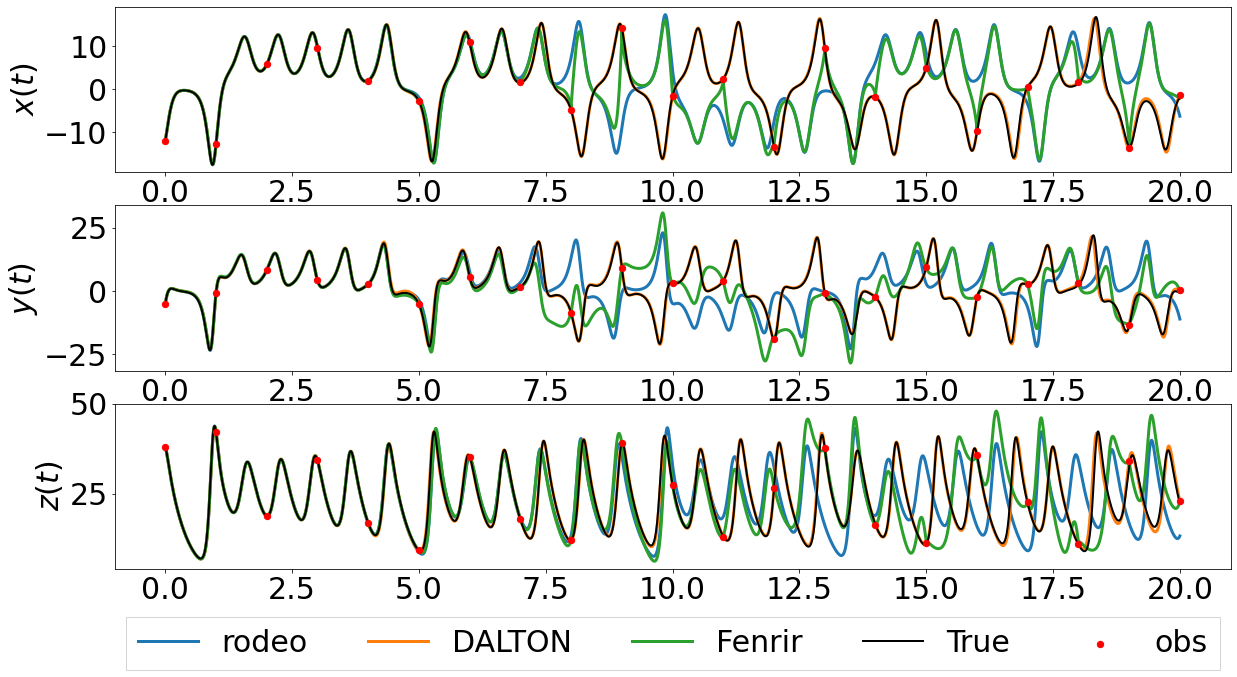

In [14]:
# exact solution
tseq_sim = np.linspace(tmin, tmax, n_steps+1)
exact = odeint(lorenz0, ode0, tseq_sim, args=(theta,), rtol=1e-20)

plt.rcParams.update({'font.size': 30})
fig, axs = plt.subplots(n_var, figsize=(20, 10))
ylabel = [r'$x(t)$', r'$y(t)$', r'$z(t)$']

for i in range(n_var):
    l0, = axs[i].plot(tseq_sim, rodeo[:, i, 0], label="rodeo", linewidth=3)
    l1, = axs[i].plot(tseq_sim, dalton[:, i, 0], label="DALTON", linewidth=3)
    l2, = axs[i].plot(tseq_sim, fenrir[:, i, 0], label="Fenrir", linewidth=3)
    l3, = axs[i].plot(tseq_sim, exact[:, i], label='True', linewidth=2, color="black")
    l4 = axs[i].scatter(tseq, obs[:, i], label='Obs', color='red', s=40, zorder=3)
    axs[i].set(ylabel=ylabel[i])
handles = [l0, l1, l2, l3, l4]
fig.subplots_adjust(bottom=0.1, wspace=0.33)

axs[2].legend(handles = handles , labels=['rodeo', 'DALTON', 'Fenrir', 'True', 'obs'], loc='upper center', 
              bbox_to_anchor=(0.5, -0.2),fancybox=False, shadow=False, ncol=5)

In the plot above, we see that only `dalton` is able to recover the true ODE solution beyond $t>7.5$.